<a href="https://colab.research.google.com/github/gehrywhy/lab4-project/blob/master/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Text_processing_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ текстовых данных

В этом ноутбуке вы научитесь:
1. Очищать текст (приводить к нижнему регистру, удалять знаки препинания)
2. Проводить лемматизацию ( приводить все слова к основе) с помощью pymorphy3
3. Считать частоту слов
4. Удалять стоп-слова
5. Вычислять TF-IDF слов
6. И даже реализуете свой информационный поиск по Вашему корпусу текста

Сгенерируем небольшой набор данных, представляющий собой 5 положительных и 5 отрицательных отзывов на товар.

In [ ]:
import pandas as pd

# Загружаем наш JSONL файл
df = pd.read_json('instructions.jsonl', lines=True)

# Смотрим первые 5 строк
df.head(

,instruction,input,output
0,Проанализируй текст делового письма и извлеки ...,"ЗАО «Савина Некрасов»\nклх Билибино, алл. Гафу...","{""correspondent"": ""ЗАО «Савина Некрасов», клх ..."
1,Проанализируй текст делового письма и извлеки ...,"ИП «Смирнова, Моисеева и Исаев»\nклх Джубга, п...","{""correspondent"": ""ИП «Смирнова, Моисеева и Ис..."
2,Проанализируй текст делового письма и извлеки ...,"ООО «Сорокин, Носова и Панфилов»\nс. Белгород,...","{""correspondent"": ""ООО «Сорокин, Носова и Панф..."
3,Проанализируй текст делового письма и извлеки ...,"Игнатов Инкорпорэйтед\nд. Кашира, бул. Путейск...","{""correspondent"": ""Игнатов Инкорпорэйтед, д. К..."
4,Проанализируй текст делового письма и извлеки ...,"ООО «Блинов, Осипова и Дроздова»\nст. Кострома...","{""correspondent"": ""ООО «Блинов, Осипова и Дроз..."


## 1. Очистка текста

Прежде всего "очистим" текст.

Компьютер воспринимает `"СУПЕР"`, `"Супер"` и `"супер"` как три разных слова.  Чтобы это исправить, приводим все слова к нижнему регистру.

Также удалим знаки препинания (восклицательные знаки, запятые и т.д.), т.е. они не несут смысла.

Для этого используем регулярные выражения (`re.sub`).

In [ ]:
import re
import pandas as pd
# Берем первые 2 строки из нашего датасета
examples_df = df[['input', 'clean_text']].head(2).copy()

# Переименовываем колонки для красоты
examples_df.columns = ['Исходный текст письма', 'Очищенный текст']

# Выводим как красивую HTML-таблицу
display(examples_df)
def clean_text(text):
    # Защита от пустых значений (NaN / null)
    if pd.isna(text):
        return ""

    # Принудительно делаем текстом и переводим в нижний регистр
    text = str(text).lower()

    # Удаляем всё, кроме русских букв и пробелов
    text = re.sub(r'[^а-яё ]', '', text)

    # Убираем лишние пробелы и переносы строк (\n)
    text = ' '.join(text.split())

    return text
# Берем первые 2 строки из нашего датасета
examples_df = df[['input', 'clean_text']].head(2).copy()

# Переименовываем колонки для красоты
examples_df.columns = ['Исходный текст письма', 'Очищенный текст']

# Выводим как красивую HTML-таблицу
display(examples_df)
# В нашем датасете текст письма находится в колонке 'input'
df['clean_text'] = df['input'].apply(clean_text)

# Покажем, как изменился текст (используем iloc[0] для первой строки)
print("=== ДО ===")
print(df['input'].iloc[0])
print("\n=== ПОСЛЕ ===")
print(df['clean_text'].iloc[0])

,Исходный текст письма,Очищенный текст
0,"ЗАО «Савина Некрасов»\nклх Билибино, алл. Гафу...",зао савина некрасовклх билибино алл гафури д к...
1,"ИП «Смирнова, Моисеева и Исаев»\nклх Джубга, п...",ип смирнова моисеева и исаевклх джубга пр тупи...


,Исходный текст письма,Очищенный текст
0,"ЗАО «Савина Некрасов»\nклх Билибино, алл. Гафу...",зао савина некрасовклх билибино алл гафури д к...
1,"ИП «Смирнова, Моисеева и Исаев»\nклх Джубга, п...",ип смирнова моисеева и исаевклх джубга пр тупи...


=== ДО ===
ЗАО «Савина Некрасов»
клх Билибино, алл. Гафури, д. 2 к. 4

Дата: 01.07.1976
№ исх-867/24

ООО «Павлов-Орлова»
Директору
Евграф Дорофеевич Владимиров

ИНФОРМАЦИОННОЕ ПИСЬМО
Уведомляем Вас о том, что согласно договору подряда, все работы на объекте завершены в полном объеме.
Просим направить представителя для подписания акта.

Директор
_________________ / Савин Аникей Демьянович /

=== ПОСЛЕ ===
зао савина некрасовклх билибино алл гафури д к дата исхооо павловорловадиректоруевграф дорофеевич владимировинформационное письмоуведомляем вас о том что согласно договору подряда все работы на объекте завершены в полном объемепросим направить представителя для подписания актадиректор савин аникей демьянович


## 2. Лемматизация (приведение слов к начальной форме)

Слова `"заказывать"`, `"заказываю"`, `"заказал"` — для компьютера это разные слова, но для человека это одно и то же.

**Лемматизация** приводит слова к их начальной форме:
- `"заказывать"`, `"заказываю"` → `"заказывать"`
- `"товары"`, `"товаром"` → `"товар"`
- `"лучше"`, `"лучший"` → `"лучший"`

Для русского языка используем библиотеку `pymorphy3` — морфологический анализатор для русского языка. Она умеет определять часть речи, число, падеж и начальную форму слова.

In [ ]:
# Установка библиотеки (раскомментируйте и запустите один! раз)
#!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 78.4 MB/s eta 0:00:00


In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()                     # Создаём анализатор

# Пример работы лемматизации
word = "стали"
parsed = morph.parse(word)[0]                         # одно и тоже слово может иметь разные значения, здесь берется нулевое -- наиболее вероятное
print(f"Слово: {word}")
print(f"Лемма: {parsed.normal_form}")                 # выводим начальную форму слова
print(f"Часть речи: {parsed.tag.POS}")                # часть речи

Слово: стали
Лемма: стать
Часть речи: VERB


In [ ]:
def lemmatize_text(text):
    """
    Разбивает текст на слова и каждое слово приводит к начальной форме.
    """
    words = text.split()                                           # Разбиваем на слова
    lemmas = [morph.parse(word)[0].normal_form for word in words]  # Лемматизируем каждое
    return ' '.join(lemmas)                                        # Собираем обратно в строку

# Применяем функцию ко всем текстам в датасете
df['lemmas'] = df['clean_text'].apply(lemmatize_text)

Выведем таблицу с исходным текстом, после очистки, после лемматизации. Проанализируйте, как менялся текст на каждом этапе.

In [ ]:
df

,instruction,input,output,clean_text,lemmas
0,Проанализируй текст делового письма и извлеки ...,"ЗАО «Савина Некрасов»\nклх Билибино, алл. Гафу...","{""correspondent"": ""ЗАО «Савина Некрасов», клх ...",зао савина некрасовклх билибино алл гафури д к...,зао савин некрасовклха билибино алл гафурить д...
1,Проанализируй текст делового письма и извлеки ...,"ИП «Смирнова, Моисеева и Исаев»\nклх Джубга, п...","{""correspondent"": ""ИП «Смирнова, Моисеева и Ис...",ип смирнова моисеева и исаевклх джубга пр тупи...,ип смирнов моисеев и исаевклха джубга пр тупик...
2,Проанализируй текст делового письма и извлеки ...,"ООО «Сорокин, Носова и Панфилов»\nс. Белгород,...","{""correspondent"": ""ООО «Сорокин, Носова и Панф...",ооо сорокин носова и панфиловс белгород наб бе...,ооо сорокин носов и панфиловс белгород наб бел...
3,Проанализируй текст делового письма и извлеки ...,"Игнатов Инкорпорэйтед\nд. Кашира, бул. Путейск...","{""correspondent"": ""Игнатов Инкорпорэйтед, д. К...",игнатов инкорпорэйтедд кашира бул путейский д ...,игнат инкорпорэйтедда кашира бул путейский дал...
4,Проанализируй текст делового письма и извлеки ...,"ООО «Блинов, Осипова и Дроздова»\nст. Кострома...","{""correspondent"": ""ООО «Блинов, Осипова и Дроз...",ооо блинов осипова и дроздоваст кострома наб к...,ооо блин осипов и дроздовастый кострома наб ки...
...,...,...,...,...,...
495,Проанализируй текст делового письма и извлеки ...,"Некрасов Лимитед\nг. Комсомольск-на-Амуре, бул...","{""correspondent"": ""Некрасов Лимитед, г. Комсом...",некрасов лимитедг комсомольскнаамуре бул есени...,некрасов лимитедг комсомольскнаамур бул есенин...
496,Проанализируй текст делового письма и извлеки ...,"АО «Кулакова-Савельева»\nд. Юрюзань, алл. Меха...","{""correspondent"": ""АО «Кулакова-Савельева», д....",ао кулаковасавельевад юрюзань алл механизаторо...,ао кулаковасавельевада юрюзань алл механизатор...
497,Проанализируй текст делового письма и извлеки ...,"Фокина Инк\nп. Яшалта, наб. Революции, д. 1 ст...","{""correspondent"": ""Фокина Инк, п. Яшалта, наб....",фокина инкп яшалта наб революции д стр дата ис...,фокин инкп яшалта наб революция далее стр дата...
498,Проанализируй текст делового письма и извлеки ...,"ЗАО «Доронина»\nс. Льгов, наб. Чкалова, д. 226...","{""correspondent"": ""ЗАО «Доронина», с. Льгов, н...",зао доронинас льгов наб чкалова д дата исхзао ...,зао доронинас льгов наб чкалов далее дата исхз...


## 3. Подсчёт частоты слов

Посмотрим, какие слова встречаются в наших отзывах чаще всего.
Для этого:


*   Объединим все лемматизированные тексты в один список слов
*   Посчитаем частоту каждого слова с помощью Counter
*   Выведем топ-10 самых частых слов

In [ ]:
from collections import Counter

# Объединяем все леммы в один список слов
all_words = ' '.join(df['lemmas']).split()

# Считаем частоту каждого слова
word_counts = Counter(all_words)

print("Топ-10 самых частых слов:")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")

Топ-10 самых частых слов:
далее: 502
дата: 500
письмоуведомлять: 500
вы: 500
о: 500
тот: 500
что: 500
согласно: 500
договор: 500
подряд: 500


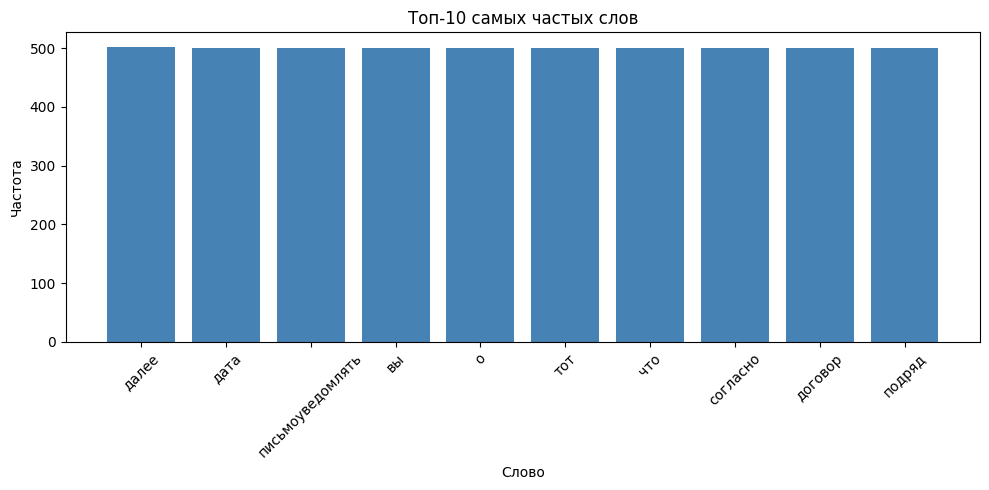

In [ ]:
# Строим столбчатый график топ-10 слов
import matplotlib.pyplot as plt

# Берём топ-10 и разделяем на слова и частоты
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Топ-10 самых частых слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Интересную возможность для визуализации дает **облако слов (Word Cloud)** —  способ наглядно показать, какие слова встречаются чаще всего.
**Чем чаще слово**, тем оно **крупнее** на картинке.

Облако слов помогает быстро увидеть:
- Основные темы в текстах
- Какие слова доминируют
- Различия между категориями (если строить отдельно для каждой)

**Параметр `max_words=10`** показывает только топ-10 самых частых слов, чтобы не перегружать картинку. Попробуйте убрать его и построить все слова, будет очень красиво.

In [ ]:
# Установка (один раз)
!pip install wordcloud

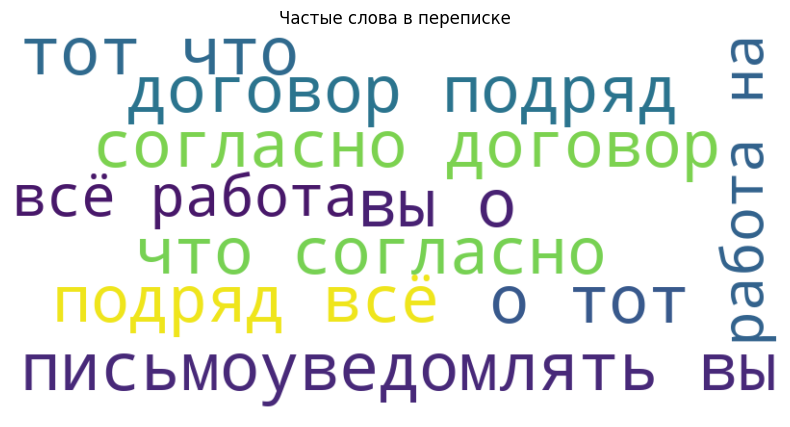

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Создаём облако слов
all_text = ' '.join(df['lemmas'])
wc = WordCloud(width=800, height=400,  max_words=10, background_color='white').generate(all_text)

# Показываем
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в переписке')
plt.show()

Можно построить облака слов для наших категорий - позитивных и негативных отзывов.

In [ ]:
# Облако слов для "Позитива"
pos_text = ' '.join(df[df['category'] == 'Позитив']['lemmas'])
wc_pos = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(pos_text)

# Облако слов для "Негатива"
neg_text = ' '.join(df[df['category'] == 'Негатив']['lemmas'])
wc_neg = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Позитив', fontsize=14)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Негатив', fontsize=14)

plt.tight_layout()
plt.show()

KeyError: 'category'

## 4. Удаление стоп-слов

Как мы видим, самым частым словом у нас оказалось "не".
Слова "не", "и", "в", "на" и т.д. встречаются почти в любом тексте, но не несут полезного смысла для анализа.
Такие слова называют стоп-словами и обычно перед анализом текста их удаляют.
Возьмём готовый список русских стоп-слов из библиотеки nltk.

In [ ]:
import nltk
from nltk.corpus import stopwords

# Скачиваем список стоп-слов
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('russian'))         # загружаем русские стоп-слова

print("Примеры стоп-слов:", list(stop_words)[:20])   # первые 20 стоп-слов

# удаляем стоп-слова из наших лемматизированных текстов
def remove_stopwords(text, stop_words):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

df['no_stopwords'] = df['lemmas'].apply(lambda x: remove_stopwords(x, stop_words))

Примеры стоп-слов: ['его', 'как', 'если', 'а', 'только', 'больше', 'вот', 'даже', 'вам', 'и', 'по', 'эту', 'может', 'когда', 'ее', 'про', 'этой', 'до', 'всю', 'от']


Вновь проанализируйте, как изменился текст после удаления стоп-слов.

In [ ]:
df

,instruction,input,output,clean_text,lemmas,no_stopwords
0,Проанализируй текст делового письма и извлеки ...,"ЗАО «Савина Некрасов»\nклх Билибино, алл. Гафу...","{""correspondent"": ""ЗАО «Савина Некрасов», клх ...",зао савина некрасовклх билибино алл гафури д к...,зао савин некрасовклха билибино алл гафурить д...,зао савин некрасовклха билибино алл гафурить д...
1,Проанализируй текст делового письма и извлеки ...,"ИП «Смирнова, Моисеева и Исаев»\nклх Джубга, п...","{""correspondent"": ""ИП «Смирнова, Моисеева и Ис...",ип смирнова моисеева и исаевклх джубга пр тупи...,ип смирнов моисеев и исаевклха джубга пр тупик...,ип смирнов моисеев исаевклха джубга пр тупиков...
2,Проанализируй текст делового письма и извлеки ...,"ООО «Сорокин, Носова и Панфилов»\nс. Белгород,...","{""correspondent"": ""ООО «Сорокин, Носова и Панф...",ооо сорокин носова и панфиловс белгород наб бе...,ооо сорокин носов и панфиловс белгород наб бел...,ооо сорокин носов панфиловс белгород наб белин...
3,Проанализируй текст делового письма и извлеки ...,"Игнатов Инкорпорэйтед\nд. Кашира, бул. Путейск...","{""correspondent"": ""Игнатов Инкорпорэйтед, д. К...",игнатов инкорпорэйтедд кашира бул путейский д ...,игнат инкорпорэйтедда кашира бул путейский дал...,игнат инкорпорэйтедда кашира бул путейский дал...
4,Проанализируй текст делового письма и извлеки ...,"ООО «Блинов, Осипова и Дроздова»\nст. Кострома...","{""correspondent"": ""ООО «Блинов, Осипова и Дроз...",ооо блинов осипова и дроздоваст кострома наб к...,ооо блин осипов и дроздовастый кострома наб ки...,ооо блин осипов дроздовастый кострома наб кирп...
...,...,...,...,...,...,...
495,Проанализируй текст делового письма и извлеки ...,"Некрасов Лимитед\nг. Комсомольск-на-Амуре, бул...","{""correspondent"": ""Некрасов Лимитед, г. Комсом...",некрасов лимитедг комсомольскнаамуре бул есени...,некрасов лимитедг комсомольскнаамур бул есенин...,некрасов лимитедг комсомольскнаамур бул есенин...
496,Проанализируй текст делового письма и извлеки ...,"АО «Кулакова-Савельева»\nд. Юрюзань, алл. Меха...","{""correspondent"": ""АО «Кулакова-Савельева», д....",ао кулаковасавельевад юрюзань алл механизаторо...,ао кулаковасавельевада юрюзань алл механизатор...,ао кулаковасавельевада юрюзань алл механизатор...
497,Проанализируй текст делового письма и извлеки ...,"Фокина Инк\nп. Яшалта, наб. Революции, д. 1 ст...","{""correspondent"": ""Фокина Инк, п. Яшалта, наб....",фокина инкп яшалта наб революции д стр дата ис...,фокин инкп яшалта наб революция далее стр дата...,фокин инкп яшалта наб революция далее стр дата...
498,Проанализируй текст делового письма и извлеки ...,"ЗАО «Доронина»\nс. Льгов, наб. Чкалова, д. 226...","{""correspondent"": ""ЗАО «Доронина», с. Льгов, н...",зао доронинас льгов наб чкалова д дата исхзао ...,зао доронинас льгов наб чкалов далее дата исхз...,зао доронинас льгов наб чкалов далее дата исхз...


## 5. TF-IDF: превращаем текст в числа

Компьютер не работает со словами — только с числами. Поэтому каждый текст нужно представить в виде вектора чисел. Мы воспользуемя векторайзером TfidfVectorizer, который для каждого слова вычислит "вес" TF-IDF.

Подробно о векторизации текста Вы узнает в ходе дальнейшего обучения, пока нам можно считать, что TF-IDF состоит из TF (Term Frequency), которая показывает как часто слово встречается в этом тексте и IDF (Inverse Document Frequency), которая показывает, насколько редким является слово во всем наборе данных.

Высокий вес **TF-IDF = TF × IDF**  получается, когда слово часто встречается в *этом* отзыве и редко встречается в *остальных* отзывах.  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Инициализируем векторизатор TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# Обучаем модель и трансформируем нашу колонку с полностью чистым текстом
tfidf_matrix = tfidf_vectorizer.fit_transform(df['final_text'])

# Получаем список всех уникальных слов (словарь корпуса)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"(Это означает, что у нас {tfidf_matrix.shape[0]} писем и {tfidf_matrix.shape[1]} уникальных слов в словаре)\n")

# Посмотрим на веса TF-IDF для самого первого письма в датасете
first_doc_vector = tfidf_matrix[0]

# Создадим красивую табличку для наглядности
df_tfidf = pd.DataFrame(first_doc_vector.T.todense(), index=feature_names, columns=["tfidf_weight"])
df_tfidf = df_tfidf[df_tfidf["tfidf_weight"] > 0] # Оставляем только те слова, которые есть в этом письме

print("Топ-5 самых важных (уникальных) слов для первого письма:")
print(df_tfidf.sort_values(by="tfidf_weight", ascending=False).head(5))

KeyError: 'final_text'

Мы собрали все слова из всех текстов в длинный список, у нас получилось 37 слов. Вот так выглядит сам словарь.

In [ ]:
feature_names

array(['ааронович', 'абакан', 'абб', ..., 'ясный', 'яшалта', 'яшкуль'],
      dtype=object)

Теперь каждый текст в нашем наборе данных представляет собой вектор длины 37, значения элементов которого есть TF-IDF слов словаря. Ниже приведен пример первого текста из 5 слов. Соответствующий ему вектор длины 37 содержит ровно 5 ненулевых элементов со значениями TF-IDF этих слов. Если слова нет в тексте, его TF-IDF равен нулю.


In [ ]:
# наш первый отзыв в виде вектора
print(f"Текст: {df['no_stopwords'].iloc[0]}")
print(f"Вектор:\n{tfidf_matrix[0].toarray()}")

Текст: зао савин некрасовклха билибино алл гафурить далее дата исхооо павловорловадиректоруевграф дорофеевич владимировинформационный письмоуведомлять согласно договор подряд всё работа объект завершить полный объемепросить направить представитель подписание актадиректор савин аникей демьянович
Вектор:
[[0. 0. 0. ... 0. 0. 0.]]


Теперь тексты можно сравнивать, искать, классифицировать и т.д.

## 6. Информационный поиск

Найдем тексты, которые **наиболее похожи** на поисковый запрос или, другими словами, найдем вектора наших текстов **наиболее похожие** на вектор запроса.

Для измерения похожести векторов обычно используется **косинусное сходство** (cosine similarity), которое равно **1**, если векторы одинаковые.
Подробнее об этой метрике и других Вы также узнаете в ходе дальнейшего обучения.

Реализуем простой поиск.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# функция поиска наиболее близких текстов к запросу
def search_texts(query, vectorizer, tfidf_matrix, texts, top_n=3):
    """
    Ищет top_n текстов, наиболее похожих на запрос.
    """
    query = clean_text(query)            # очищаем запрос
    query = lemmatize_text(query)        # лемматизируем запрос
    query_vec = vectorizer.transform([query])  # векторизуем запрос

    # считаем похожесть запроса со всеми текстами
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

    # находим индексы топ-n самых похожих
    top_indices = similarities.argsort()[-top_n:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'Текст': texts.iloc[idx],
            'Похожесть': similarities[idx]
        })

    return results

Приведем пример использования функции поиска. Предположим пользователь вводит в строке поиска "Качество товара".
Найдем текст в нашем наборе данных наиболее близкий к данному запросу.

In [ ]:
# Пример поиска
query = "Качество товара"
results = search_texts(query, vectorizer, tfidf_matrix, df['no_stopwords'], top_n=3)

print(f"Поисковый запрос: '{query}'")
print(f"\nНайдено {len(results)} наиболее похожих отзывов:\n")
for i, res in enumerate(results, 1):
    print(f"{i}. Похожесть: {res['Похожесть']:.8f}")
    print(f"   Текст: {res['Текст']}")

Поисковый запрос: 'Качество товара'

Найдено 3 наиболее похожих отзывов:

1. Похожесть: 0.52803897
   Текст: качество товар высота заказывать ещё
2. Похожесть: 0.52803897
   Текст: ужасный качество товар советовать никто
3. Похожесть: 0.21068519
   Текст: плохой покупка жизнь рекомендовать товар


Проанализируйте полученный результат. Первыми были выведены те тексты, которые содержали оба слова из запроса. Какая похожесть у этих текстов? Что можно сказать о третьем тексте?

# Задание

**Найти текстовый набор данных**, в соответствии с файлом инструкцией, в котором изложены требования.


Примените все 6 шагов из учебного ноутбука к Вашему датасету (лучше, чтобы язык был русский. В противном случае вместо pymorphy используйте nltk и spacy).

**1. Очистка текста**
- Приведите к нижнему регистру
- Удалите знаки препинания и лишние пробелы
- Выведите 2–3 примера до и после очистки

**2. Лемматизация**
- Примените pymorphy3 ко всем текстам
- Выведите 2–3 примера до и после лемматизации

**3. Подсчёт частоты слов**
- Посчитайте топ-10 самых частых слов
- Постройте столбчатый график
- Постройте облако слов (WordCloud)

**4. Удаление стоп-слов**
- Загрузите список стоп-слов
- Удалите их из текстов
- Посчитайте топ-10 слов после удаления
- Выведите примеры текстов до и после

**5. TF-IDF**
- Векторизуйте тексты через TfidfVectorizer
- Выведите размер словаря
- Покажите пример вектора для одного текста

**6. Информационный поиск**
- Реализуйте функцию поиска
- Протестируйте на 2–3 запросах
- Покажите результаты поиска (текст + похожесть)
